# Assignment Module 2: Pet Classification

The goal of this assignment is to implement a neural network that classifies images of 37 breeds of cats and dogs from the [Oxford-IIIT-Pet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). The assignment is divided into two parts: first, you will be asked to implement from scratch your own neural network for image classification; then, you will fine-tune a pretrained network provided by PyTorch.

### Import

In [1]:
!git clone https://github.com/CVLAB-Unibo/ipcv-assignment-2.git

Cloning into 'ipcv-assignment-2'...
remote: Enumerating objects: 7371, done.
remote: Total 7371 (delta 0), reused 0 (delta 0), pack-reused 7371 (from 1)
Receiving objects: 100% (7371/7371), 753.77 MiB | 57.61 MiB/s, done.
Updating files: 100% (7396/7396), done.


In [2]:
!pip install -q wandb
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 29.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 5.7 MB/s eta 0:00:000:00:0100:01


In [3]:
from pathlib import Path
from PIL import Image
from torch import Tensor
from torch.utils.data import Dataset
from typing import Any, Callable, Dict, List, Optional, Tuple
import random
import time
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, AdamW
from torch.utils.data import random_split, DataLoader
from torchvision import transforms as T, datasets
import torchvision.transforms.v2 as v2
from torch.optim.lr_scheduler import OneCycleLR, ReduceLROnPlateau, CosineAnnealingLR
from torchmetrics.classification.accuracy import Accuracy
import copy
from torchvision.models import resnet18, ResNet18_Weights
import wandb

print("Using torch", torch.__version__)

Using torch 2.6.0+cu124


### Dataset

The following cells contain the code to download and access the dataset you will be using in this assignment. Note that, although this dataset features each and every image from [Oxford-IIIT-Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/), it uses a different train-val-test split than the original authors.

In [4]:
class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()

        self.root = Path("ipcv-assignment-2") / "dataset"
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

In [5]:
def get_datasets(train_transformer,test_transformer, batch_size):

    # --- Datasets ---
    train_dset = OxfordPetDataset(
        split="train",
        transform=train_transformer
    )
    val_dset = OxfordPetDataset(
        split="val",
        transform=test_transformer,
    )
    test_dset = OxfordPetDataset(
        split="test",
        transform=test_transformer,
    )

    # --- DataLoaders ---
    train_dl = DataLoader(
        train_dset,
        batch_size=batch_size,
        shuffle=True
    )
    val_dl = DataLoader(
        val_dset,
        batch_size=batch_size
    )
    test_dl = DataLoader(
        test_dset,
        batch_size=batch_size
    )

    return train_dl, val_dl, test_dl

### Fix randomness

In [6]:
def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(33)

### GPU check

In [7]:
gpu_avail = torch.cuda.is_available()
print(f"Is the GPU available? {gpu_avail}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device: {device}")

Is the GPU available? True
Device: cuda


### Free memory

In [8]:
import gc

torch.cuda.empty_cache()
gc.collect()

259

### Trainer class

In [9]:
class Trainer:
    def __init__(self,
                 model: nn.Module,
                 train_loader: DataLoader,
                 val_loader: DataLoader,
                 test_loader: DataLoader,
                 device: torch.device,
                 num_classes: int,
                 cfg: Dict[str, Any],
                 wandb_credentials: Optional[Tuple[str, str]] = None,
                 verbose: bool = False,
                 ) -> None:

        # Loaders
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader

        # Model to device
        self.device = device
        self.model = model.to(device)

        # Classes
        self.num_classes = num_classes

        # Epochs
        self.num_epochs = cfg["num_epochs"]

        # Optimizer
        self.optimizer = AdamW(self.model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])

        # Scheduler
        if cfg["scheduler"]:
          num_steps = self.num_epochs * len(train_loader)
          self.scheduler = OneCycleLR(self.optimizer, cfg["lr"], total_steps=num_steps)

        # Batch transformations (MixUp, CutMix, ...)
        self.batch_transforms = cfg["batch_transforms"]

        # Stats
        self.step = 0
        self.best_acc = 0.0
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []

        # Wandb credentials
        self.wandb_credentials = wandb_credentials
        if self.wandb_credentials is not None:
          WANDB_USER, WANDB_PROJECT = self.wandb_credentials
          wandb.init(name=cfg["run_name"], entity=WANDB_USER, project=WANDB_PROJECT, config=cfg)

        # Path for saving model
        self.ckpt_path = Path("ckpts")
        self.ckpt_path.mkdir(exist_ok=True)

        # Verbose
        self.verbose = verbose


    def logfn(self, values: Dict[str, Any]) -> None:
        wandb.log(values, step=self.step, commit=False)

    def train(self) -> None:
        for _ in tqdm(range(self.num_epochs), desc="Epoch"):
            self.model.train()

            for imgs, labels in self.train_loader:
                imgs = imgs.to(self.device)
                labels = labels.to(self.device)

                if self.batch_transforms:
                  imgs, labels = self.batch_transforms(imgs, labels)

                pred = self.model(imgs)
                loss = F.cross_entropy(pred, labels)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                self.scheduler.step()

                if self.wandb_credentials:
                    self.logfn({"train/loss": loss.item()})
                    self.logfn({"train/lr": self.scheduler.get_last_lr()[0]})

                self.step += 1

            if self.verbose:
              print(f"Epoch {_+1}")

            train_loss, train_accuracy = self.eval("train")
            val_loss, val_accuracy = self.eval("val")

            self.train_loss.append(train_loss)
            self.train_acc.append(train_accuracy)
            self.val_loss.append(val_loss)
            self.val_acc.append(val_accuracy)

        if self.wandb_credentials:
          wandb.finish()

    @torch.no_grad()
    def eval(self, split: str) -> Tuple[float, float]:

        if split=="test":
            model_to_eval = self.best_model
        else:
            model_to_eval = self.model

        model_to_eval.eval()

        loader = self.train_loader if split == "train" else self.val_loader if split == "val" else self.test_loader
        acc = Accuracy("multiclass", num_classes=self.num_classes).to(self.device)

        losses = []
        for imgs, labels in loader:
            imgs = imgs.to(self.device)
            labels = labels.to(self.device)

            pred = model_to_eval(imgs)
            loss = F.cross_entropy(pred, labels)
            losses.append(loss.item())

            pred_softmax = F.softmax(pred, dim=-1)
            acc(pred_softmax, labels)

        loss = sum(losses) / len(losses)
        accuracy = float(acc.compute())

        if self.wandb_credentials:
          self.logfn({f"{split} loss": loss})
          self.logfn({f"{split} acc": accuracy})
        elif self.verbose:
          print(f"\t{split} loss {loss:.3f} - {split} accuracy {accuracy:.3f}")

        if accuracy > self.best_acc and split == "val":
            self.best_acc = accuracy
            if self.wandb_credentials:
              torch.save(model_to_eval.state_dict(), self.ckpt_path / f"{wandb.run.name}.pt")
            else:
              torch.save(model_to_eval.state_dict(), self.ckpt_path / "best_model.pt")

            self.best_model = copy.deepcopy(model_to_eval)

        return loss, accuracy

### Plot the history

In [10]:
def plot_history(history):

  fig, axes = plt.subplots(1, 2, figsize=(10,4))

  # Loss
  axes[0].plot(history["train_loss"], label="train")
  if history["val_loss"]:
      axes[0].plot(history["val_loss"], label="val")
  axes[0].set_title("Loss")
  axes[0].legend()

  # Accuracy
  axes[1].plot(history["train_acc"], label="train")
  if history["val_acc"]:
      axes[1].plot(history["val_acc"], label="val")
  axes[1].set_title("Accuracy")
  axes[1].legend()

  plt.tight_layout()
  plt.show()

## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `OxfordPetDataset`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~60%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~60% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

### CNN Architecture

In [11]:
# --- Residual Blocks ---

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = torch.relu(out)
        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = torch.relu(self.bn1(self.conv1(x)))
        out = torch.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = torch.relu(out)
        return out


# --- General ResNet ---

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=37, input_channels=3, dropout=0.5):
        super(ResNet, self).__init__()
        self.in_channels = 64

        # Initial stem
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Adaptive pooling for variable input size
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x

# --- Known ResNet architectures ---

def resnet18(num_classes, input_channels=3):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes, input_channels, dropout=0.5)


def resnet34(num_classes, input_channels=3):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes, input_channels, dropout=0.5)


def resnet50(num_classes, input_channels=3):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes, input_channels, dropout=0.5)

### Model A (best)

Architecture:
- resnet [2,3,4,2]
- bottleneck blocks
- dropout

Training recipes:
- trivial augmentation
- long training
- lr scheduler (OneCycle)
- image resizing
- mixup
- cutmix
- AdamW optimizer

In [12]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

cfg_A = {
    # Pre-processing's parameters.
    "resize_size": 256,
    "crop_size": 224,

    # Training's parameters.
    "batch_size": 128,
    "num_epochs": 100,

    # Optimizer's parameters.
    "lr": 1e-3,
    "wd": 1e-4,
    "step_size": 5,

    # Batch transformations
    "batch_transforms" : v2.Compose([
        v2.MixUp(alpha=1.0, num_classes=n_classes),     # MIXUP
        v2.CutMix(alpha=1.0, num_classes=n_classes),    # CUTMIX
    ]),

    # Scheduler
    "scheduler":True,

    # Model
    'block_type': Bottleneck,
    'block_depths': [2, 3, 4, 2],
    'num_classes': n_classes,
    'input_channels': 3,
    'dropout': 0.5
}

# --- Transform for Data Augmentation and Img Resizing ---

train_transformer_A = T.Compose([
    T.RandomResizedCrop(cfg_A["crop_size"], scale=(0.8, 1.0)),     # RANDOM CROP RESIZE
    T.RandomHorizontalFlip(),                       # TRIVIAL AUGMENTATION
    T.ToTensor(),
    T.ConvertImageDtype(torch.float),
    T.RandomErasing(p=0.5,                          # RANDOM ERASING
                    scale=(0.02, 0.33),
                    ratio=(0.3, 3.3),
                    value=0,
                    inplace=False),
])

test_transformer_A = T.Compose([
    T.Resize(cfg_A["resize_size"]),                                  # RESIZE
    T.CenterCrop(cfg_A["crop_size"]),                              # CENTER CROP
    T.ToTensor(),
])

# --- DataLoaders ---

train_dl_A, val_dl_A, test_dl_A = get_datasets(train_transformer_A,
                                               test_transformer_A,
                                               cfg_A["batch_size"])

# --- Model ---

model_A = ResNet(cfg_A['block_type'],
             cfg_A['block_depths'],
             cfg_A['num_classes'],
             cfg_A['input_channels'],
             cfg_A['dropout'])

trainer_A = Trainer(
    model=model_A,
    train_loader=train_dl_A,
    val_loader=val_dl_A,
    test_loader=test_dl_A,
    device=device,
    num_classes=n_classes,
    cfg=cfg_A,
    verbose=True
)

trainer_A.train()


Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1
	train loss 3.668 - train accuracy 0.031
	val loss 3.665 - val accuracy 0.029
Epoch 2
	train loss 3.592 - train accuracy 0.044
	val loss 3.604 - val accuracy 0.038
Epoch 3
	train loss 3.650 - train accuracy 0.056
	val loss 3.599 - val accuracy 0.056
Epoch 4
	train loss 3.696 - train accuracy 0.061
	val loss 3.570 - val accuracy 0.066
Epoch 5
	train loss 3.573 - train accuracy 0.087
	val loss 3.485 - val accuracy 0.099
Epoch 6
	train loss 3.560 - train accuracy 0.092
	val loss 3.512 - val accuracy 0.086
Epoch 7
	train loss 3.419 - train accuracy 0.085
	val loss 3.395 - val accuracy 0.074
Epoch 8
	train loss 3.475 - train accuracy 0.100
	val loss 3.444 - val accuracy 0.070
Epoch 9
	train loss 3.306 - train accuracy 0.134
	val loss 3.337 - val accuracy 0.111
Epoch 10
	train loss 3.249 - train accuracy 0.129
	val loss 3.317 - val accuracy 0.117
Epoch 11
	train loss 3.484 - train accuracy 0.138
	val loss 3.353 - val accuracy 0.122
Epoch 12
	train loss 3.965 - train accuracy 0.128
	v

In [13]:
test_loss, test_accuracy = trainer_A.eval("test")

	test loss 1.504 - test accuracy 0.609


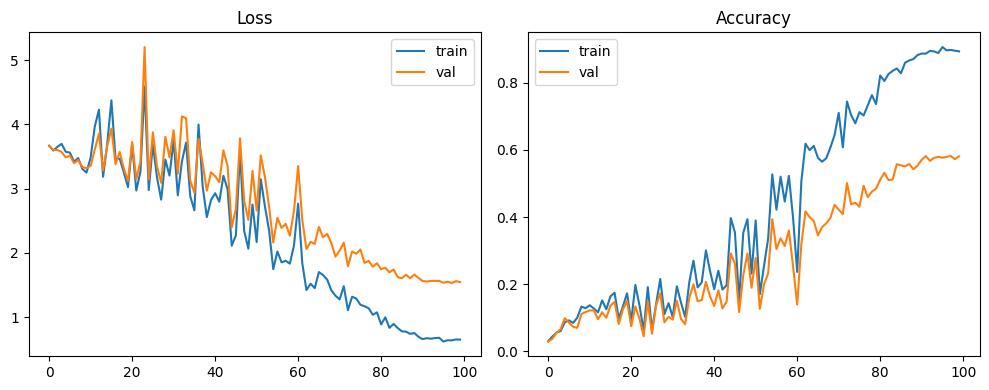

In [15]:
history_A = {
    "train_loss":trainer_A.train_loss,
    "train_acc":trainer_A.train_acc,
    "val_loss":trainer_A.val_loss,
    "val_acc":trainer_A.val_acc
}

plot_history(history_A)

### Model B

Architecture:
- resnet [2,3,4,2]
- normal residual blocks
- dropout

Same training recipes


In [12]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

cfg_B = {
    # Pre-processing's parameters.
    "resize_size": 256,
    "crop_size": 224,

    # Training's parameters.
    "batch_size": 128,
    "num_epochs": 100,

    # Optimizer's parameters.
    "lr": 1e-3,
    "wd": 1e-4,
    "step_size": 5,

    # Batch transformations
    "batch_transforms" : v2.Compose([
        v2.MixUp(alpha=1.0, num_classes=n_classes),     # MIXUP
        v2.CutMix(alpha=1.0, num_classes=n_classes),    # CUTMIX
    ]),

    # Scheduler
    "scheduler":True,

    # Model
    'block_type': BasicBlock,
    'block_depths': [2, 3, 4, 2],
    'num_classes': n_classes,
    'input_channels': 3,
    'dropout': 0.5
}

# --- Transform for Data Augmentation and Img Resizing ---

train_transformer_B = T.Compose([
    T.RandomResizedCrop(cfg_B["crop_size"], scale=(0.8, 1.0)),     # RANDOM CROP RESIZE
    T.RandomHorizontalFlip(),                       # TRIVIAL AUGMENTATION
    T.ToTensor(),
    T.ConvertImageDtype(torch.float),
    T.RandomErasing(p=0.5,                          # RANDOM ERASING
                    scale=(0.02, 0.33),
                    ratio=(0.3, 3.3),
                    value=0,
                    inplace=False),
])

test_transformer_B = T.Compose([
    T.Resize(cfg_B["resize_size"]),                                  # RESIZE
    T.CenterCrop(cfg_B["crop_size"]),                              # CENTER CROP
    T.ToTensor(),
])

# --- DataLoaders ---

train_dl_B, val_dl_B, test_dl_B = get_datasets(train_transformer_B,
                                               test_transformer_B,
                                               cfg_B["batch_size"])

# --- Model ---

model_B = ResNet(cfg_B['block_type'],
             cfg_B['block_depths'],
             cfg_B['num_classes'],
             cfg_B['input_channels'],
             cfg_B['dropout'])

trainer_B = Trainer(
    model=model_B,
    train_loader=train_dl_B,
    val_loader=val_dl_B,
    test_loader=test_dl_B,
    device=device,
    num_classes=n_classes,
    cfg=cfg_B,
    verbose=True
)

trainer_B.train()

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1
	train loss 3.794 - train accuracy 0.038
	val loss 3.799 - val accuracy 0.039
Epoch 2
	train loss 3.522 - train accuracy 0.063
	val loss 3.642 - val accuracy 0.052
Epoch 3
	train loss 3.338 - train accuracy 0.089
	val loss 3.374 - val accuracy 0.084
Epoch 4
	train loss 3.358 - train accuracy 0.091
	val loss 3.452 - val accuracy 0.082
Epoch 5
	train loss 3.269 - train accuracy 0.120
	val loss 3.421 - val accuracy 0.097
Epoch 6
	train loss 3.588 - train accuracy 0.071
	val loss 3.568 - val accuracy 0.069
Epoch 7
	train loss 3.398 - train accuracy 0.105
	val loss 3.556 - val accuracy 0.085
Epoch 8
	train loss 3.179 - train accuracy 0.131
	val loss 3.308 - val accuracy 0.105
Epoch 9
	train loss 3.039 - train accuracy 0.183
	val loss 3.168 - val accuracy 0.137
Epoch 10
	train loss 3.008 - train accuracy 0.185
	val loss 3.152 - val accuracy 0.142
Epoch 11
	train loss 3.112 - train accuracy 0.151
	val loss 3.323 - val accuracy 0.100
Epoch 12
	train loss 3.200 - train accuracy 0.130
	v

In [13]:
test_loss, test_accuracy = trainer_B.eval("test")

	test loss 1.455 - test accuracy 0.646


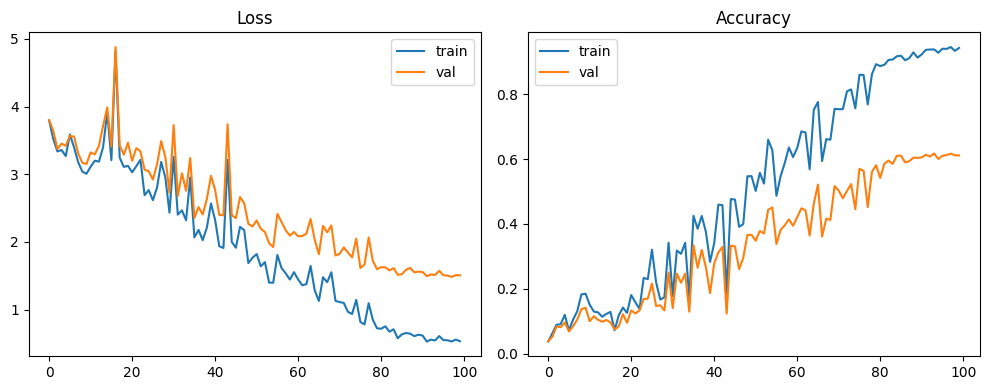

In [14]:
history_B = {
    "train_loss":trainer_B.train_loss,
    "train_acc":trainer_B.train_acc,
    "val_loss":trainer_B.val_loss,
    "val_acc":trainer_B.val_acc
}

plot_history(history_B)

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `OxfordPetDataset`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters in order to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~90%.

In [17]:
def get_model(
        num_classes: int,
        weights: Optional[ResNet18_Weights] = None
    ) -> nn.Module:
    """Gets an image classifier based on ResNet-18.

    Args:
        num_classes: the number of classes.
        weights: pretrained weights to load into the network.
                 If None, the network is randomly initialized.

    Returns:
        The required network.
    """
    model = resnet18(weights=weights)
    # Here we override the old classifier
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

def set_requires_grad(layer: torch.nn.Module, train: bool) -> None:
    """Sets the requires_grad attribute to True or False for each parameter within a layer.

        Args:
            layer: the layer to freeze.
            train: if true train the layer.
    """
    for p in layer.parameters():
        p.requires_grad = train

In [32]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

cfg_2A = {
    # Pre-processing's parameters.
    "resize_size": 256,
    "crop_size": 224,

    # Training's parameters.
    "batch_size": 128,
    "num_epochs": 10,

    # Optimizer's parameters.
    "lr": 1e-3,
    "wd": 1e-4,
    "step_size": 5,

    # Batch transformations
    "batch_transforms" : v2.Compose([
        v2.MixUp(alpha=1.0, num_classes=n_classes),     # MIXUP
        v2.CutMix(alpha=1.0, num_classes=n_classes),    # CUTMIX
    ]),

    # Scheduler
    "scheduler":True,
}

# --- Transform for Data Augmentation and Img Resizing ---

train_transformer_2A = T.Compose([
    T.RandomResizedCrop(cfg_2A["crop_size"], scale=(0.8, 1.0)),     # RANDOM CROP RESIZE
    T.RandomHorizontalFlip(),                       # TRIVIAL AUGMENTATION
    T.ToTensor(),
    T.ConvertImageDtype(torch.float),
    T.RandomErasing(p=0.5,                          # RANDOM ERASING
                    scale=(0.02, 0.33),
                    ratio=(0.3, 3.3),
                    value=0,
                    inplace=False),
])

test_transformer_2A = T.Compose([
    T.Resize(cfg_2A["resize_size"]),                                  # RESIZE
    T.CenterCrop(cfg_2A["crop_size"]),                              # CENTER CROP
    T.ToTensor(),
])

# --- DataLoaders ---

train_dl_2A, val_dl_2A, test_dl_2A = get_datasets(train_transformer_2A,
                                               test_transformer_2A,
                                               cfg_2A["batch_size"])

# --- Model ---

weights = ResNet18_Weights.IMAGENET1K_V1
model_2A = get_model(n_classes, weights).to(device)

set_requires_grad(model_2A.conv1, False)
set_requires_grad(model_2A.bn1, False)
set_requires_grad(model_2A.layer1, False)
set_requires_grad(model_2A.layer2, False)
set_requires_grad(model_2A.layer3, False)
set_requires_grad(model_2A.layer4, False)


In [33]:
trainer = Trainer(
    model=model_2A,
    train_loader=train_dl_2A,
    val_loader=val_dl_2A,
    test_loader=test_dl_2A,
    device=device,
    num_classes=n_classes,
    cfg=cfg_2A
)

trainer.train()

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

train loss 3.557 - train accuracy 0.064
val loss 3.515 - val accuracy 0.067
train loss 3.015 - train accuracy 0.289
val loss 2.934 - val accuracy 0.285
train loss 2.292 - train accuracy 0.569
val loss 2.185 - val accuracy 0.605
train loss 1.877 - train accuracy 0.667
val loss 1.754 - val accuracy 0.682
train loss 1.614 - train accuracy 0.729
val loss 1.498 - val accuracy 0.757
train loss 1.497 - train accuracy 0.744
val loss 1.392 - val accuracy 0.774
train loss 1.392 - train accuracy 0.754
val loss 1.294 - val accuracy 0.776
train loss 1.355 - train accuracy 0.785
val loss 1.261 - val accuracy 0.804
train loss 1.358 - train accuracy 0.779
val loss 1.243 - val accuracy 0.806
train loss 1.336 - train accuracy 0.784
val loss 1.242 - val accuracy 0.805


In [34]:
trainer.eval("test")

test loss 1.212 - test accuracy 0.827
